In [1]:
pip install fitparse pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fitparse: filename=fitparse-1.2.0-py3-none-any.whl size=68214 sha256=5cfeb1a2e4a4daebfea44ec32cee97f15d84679642bceb62aa7d6e7c642baf0f
  Stored in directory: /root/.cache/pip/wheels/70/74/f4/07ba357f689c8c76c09a5c6c399831b0cb3452dcc7703f304c
Successfully built fitparse


In [2]:
!pip install fitdecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 kB 5.6 MB/s eta 0:00:00


🔸 Starting interval analysis script...
Path to .FIT file: /content/3659643_uDRhduv.fit
Interval duration (s): 60
Number of intervals: 30
LT1 HR (bpm): 158
LT2 HR (bpm): 171
LT2 power (W): 363


/usr/local/lib/python3.12/dist-packages/fitdecode/reader.py:583: UserWarning: invalid field size 1 in definition message @ 21967 for type uint32 (expected a multiple of 4)
  warnings.warn(msg)


Laps selected: 30
Only 30 laps available; keeping all.
Global HR drift (2nd vs 1st half): +2.5%


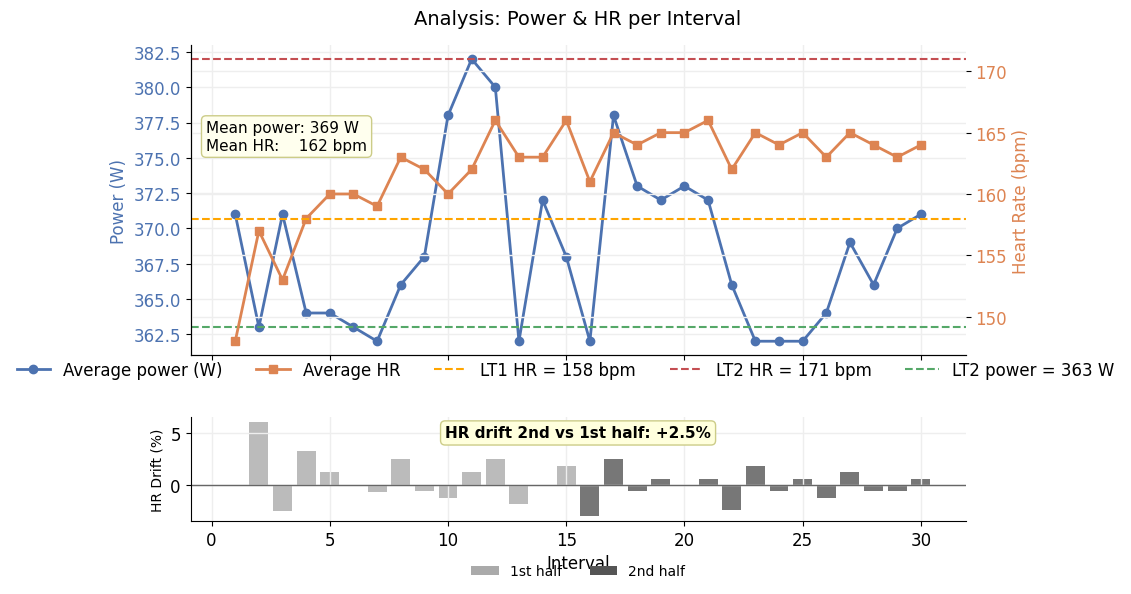

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ⬇️ on utilise fitdecode à la place de fitparse
from fitdecode import FitReader, FitDataMessage

from matplotlib.patches import Patch
import matplotlib.transforms as mtransforms


def read_laps_from_fit(fit_path):
    """
    Lire le fichier .FIT avec fitdecode et extraire les messages 'lap'.
    On récupère : temps de lap, distance, puissance moyenne et FC moyenne.
    """
    laps = []

    # FitReader gère la lecture du fichier, même avec certains champs "bizarres"
    with FitReader(fit_path) as fr:
        for frame in fr:
            # On ne garde que les vrais messages de données
            if not isinstance(frame, FitDataMessage):
                continue

            if frame.name == "lap":
                vals = {f.name: f.value for f in frame.fields}

                lap_time_s = vals.get("total_elapsed_time", None)
                distance_m = vals.get("total_distance", None)
                avg_power  = vals.get("avg_power", None)
                avg_hr     = vals.get("avg_heart_rate", None)

                laps.append({
                    "lap_time_s": lap_time_s,
                    "distance_m": distance_m,
                    "avg_power":  avg_power,
                    "avg_hr":     avg_hr
                })

    return pd.DataFrame(laps)


def remove_hr_artifacts(hr_series, max_delta=15):
    """
    Suppression des artefacts FC :
      - tout saut > max_delta bpm est considéré comme artefact
      - on remplace par NaN puis interpolation linéaire
    """
    hr = hr_series.copy().astype(float)
    diffs = hr.diff().abs()
    artifacts = diffs > max_delta
    hr[artifacts] = np.nan
    if len(hr) > 1 and pd.isna(hr.iloc[0]):
        hr.iloc[0] = hr.iloc[1]
    return hr.interpolate(method="linear")


def plot_with_hr_drift_highlight(df, lt1_hr, lt2_hr, lt2_power, drift_pct, mean_power, mean_hr):
    """
    - Haut : puissance & FC avec LT1 & LT2, + annotation des moyennes
    - Bas  : drift FC (%) par intervalle + drift global 2e vs 1re moitié
    """
    BLUE, RED, GREEN, PINK, ORANGE = "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#FFA500"
    DRIFT1, DRIFT2                = "#AAAAAA", "#555555"

    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.grid":        True,
        "grid.color":       "#EEEEEE",
        "grid.linestyle":   "-",
        "grid.linewidth":   1,
        "axes.spines.top":  False,
        "axes.spines.right":False,
        "font.size":        12,
    })

    x   = np.arange(1, len(df) + 1)
    mid = len(df) // 2

    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1,
        sharex=True,
        gridspec_kw={"height_ratios":[3, 1]},
        figsize=(10, 7)
    )

    # --- Puissance & seuil LT2 (W) ---
    line_pwr, = ax1.plot(
        x, df["avg_power_int"],
        marker="o", color=BLUE, linewidth=2, markersize=6,
        label="Average power (W)"
    )
    thresh_pwr = ax1.axhline(
        lt2_power, color=GREEN, linestyle="--", linewidth=1.5,
        label=f"LT2 power = {lt2_power:.0f} W"
    )
    ax1.set_ylabel("Power (W)", color=BLUE)
    ax1.tick_params(axis="y", labelcolor=BLUE)

    # --- FC & seuils LT1 / LT2 (bpm) ---
    ax1b = ax1.twinx()
    line_hr, = ax1b.plot(
        x, df["avg_hr_clean"],
        marker="s", color=RED, linewidth=2, markersize=6,
        label="Average HR"
    )
    thresh_lt1 = ax1b.axhline(
        lt1_hr, color=ORANGE, linestyle="--", linewidth=1.5,
        label=f"LT1 HR = {lt1_hr:.0f} bpm"
    )
    thresh_lt2 = ax1b.axhline(
        lt2_hr, color=PINK, linestyle="--", linewidth=1.5,
        label=f"LT2 HR = {lt2_hr:.0f} bpm"
    )
    ax1b.set_ylabel("Heart Rate (bpm)", color=RED)
    ax1b.tick_params(axis="y", labelcolor=RED)

    ax1.set_title("Analysis: Power & HR per Interval", pad=15, fontsize=14)

    # --- Annotation moyennes sous la ligne LT2 HR ---
    trans = mtransforms.blended_transform_factory(ax1b.transAxes, ax1b.transData)
    annotation_text = (
        f"Mean power: {mean_power:.0f} W\n"
        f"Mean HR:    {mean_hr:.0f} bpm"
    )
    ax1b.text(
        0.02,             # 2% depuis la gauche (coords axes)
        lt2_hr - 5,       # 5 bpm sous la ligne LT2
        annotation_text,
        transform=trans,
        ha="left", va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFEE", ec="#CCCC88")
    )

    # --- Légende commune ---
    handles = [line_pwr, line_hr, thresh_lt1, thresh_lt2, thresh_pwr]
    labels  = [h.get_label() for h in handles]
    fig.legend(
        handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.45),
        ncol=5,
        frameon=False
    )

    # --- Barres de HR drift ---
    colors = [DRIFT1 if i < mid else DRIFT2 for i in range(len(df))]
    ax2.bar(x, df["hr_drift_pct"], color=colors, alpha=0.8)
    ax2.axhline(0, color="#666666", linewidth=1)

    drift_text = f"HR drift 2nd vs 1st half: {drift_pct:+.1f}%"
    ax2.text(
        0.5, 0.85, drift_text,
        transform=ax2.transAxes,
        fontsize=11, fontweight="bold", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFDD", ec="#CCCC88")
    )

    patches = [
        Patch(facecolor=DRIFT1, label="1st half"),
        Patch(facecolor=DRIFT2, label="2nd half")
    ]
    ax2.legend(
        handles=patches,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.3),
        ncol=2,
        frameon=False,
        fontsize=10
    )

    ax2.set_ylabel("HR Drift (%)", fontsize=10)
    ax2.set_xlabel("Interval")

    fig.subplots_adjust(hspace=0.3, bottom=0.2)
    plt.show()


def main():
    print("🔸 Starting interval analysis script...")

    fit_file_path = input("Path to .FIT file: ").strip()
    interval_dur  = float(input("Interval duration (s): ").strip().replace(',', '.'))
    num_intervals = int(input("Number of intervals: ").strip())
    lt1_hr        = float(input("LT1 HR (bpm): ").strip().replace(',', '.'))
    lt2_hr        = float(input("LT2 HR (bpm): ").strip().replace(',', '.'))
    lt2_power     = float(input("LT2 power (W): ").strip().replace(',', '.'))

    tol           = 10  # ±10 s de tolérance
    lower, upper  = interval_dur - tol, interval_dur + tol

    if not os.path.isfile(fit_file_path):
        print("File not found.")
        return

    df = read_laps_from_fit(fit_file_path)
    df = df[df["lap_time_s"].between(lower, upper)].reset_index(drop=True)
    print(f"Laps selected: {len(df)}")
    if df.empty:
        print("No laps found – check duration or file.")
        return

    # On saute le 1er tour (échauffement)
    if len(df) >= num_intervals + 1:
        df = df.iloc[1:num_intervals+1].reset_index(drop=True)
    else:
        print(f"Only {len(df)} laps available; keeping all.")
    if df.empty:
        print("Not enough laps after selection.")
        return

    # Nettoyage FC
    df["avg_hr_clean"] = remove_hr_artifacts(df["avg_hr"], max_delta=15)

    # 0 W -> NaN puis arrondi entier pour le tracé
    df["avg_power"]     = df["avg_power"].replace(0, np.nan)
    df["avg_power_int"] = df["avg_power"].round().astype("Int64")

    # HR drift par intervalle
    df["hr_drift"]     = df["avg_hr_clean"].diff().fillna(0)
    df["hr_drift_pct"] = (df["hr_drift"] / df["avg_hr_clean"].shift(1) * 100).fillna(0)

    # Moyennes globales
    mean_power = df["avg_power"].mean()
    mean_hr    = df["avg_hr_clean"].mean()

    # HR drift global 2e vs 1re moitié
    mid        = len(df) // 2
    first_avg  = df["avg_hr_clean"].iloc[:mid].mean()
    second_avg = df["avg_hr_clean"].iloc[mid:].mean()
    drift_pct  = (second_avg - first_avg) / first_avg * 100
    print(f"Global HR drift (2nd vs 1st half): {drift_pct:+.1f}%")

    plot_with_hr_drift_highlight(df, lt1_hr, lt2_hr, lt2_power, drift_pct, mean_power, mean_hr)


if __name__ == "__main__":
    main()



🔸 Démarrage du script d'analyse d'intervalles (puissance + FC)...
Chemin vers le fichier .FIT : /content/2273647_29Qujst.fit
Durée d'un intervalle (s) : 180
Nombre d'intervalles : 10
FC LT1 (bpm) : 146
FC LT2 (bpm) : 166
Puissance LT2 (W) : 363


/usr/local/lib/python3.12/dist-packages/fitdecode/reader.py:583: UserWarning: invalid field size 1 in definition message @ 2713 for type uint32 (expected a multiple of 4)
  warnings.warn(msg)


Nombre de laps après filtrage durée : 11
Dérive FC globale (2e vs 1re moitié) : +2.1%


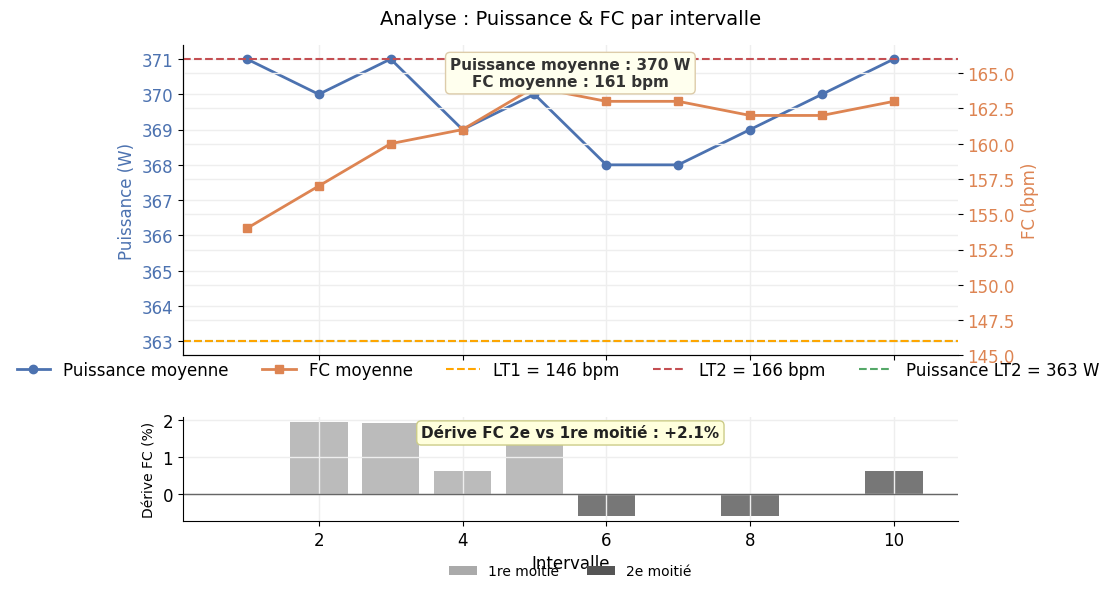

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fitdecode import FitReader, FitDataMessage
from matplotlib.patches import Patch


def read_laps_from_fit(fit_path):
    """
    Lit le fichier .FIT et extrait les laps.
    On récupère :
      - durée du lap (total_timer_time puis total_elapsed_time)
      - puissance moyenne (avg_power)
      - FC moyenne (avg_heart_rate)

    Les laps avec avg_power = 0 sont mis à NaN (ignorés ensuite).
    """
    laps = []

    with FitReader(fit_path) as fr:
        for frame in fr:
            if not isinstance(frame, FitDataMessage):
                continue
            if frame.name != "lap":
                continue

            vals = {f.name: f.value for f in frame.fields}

            timer_s   = vals.get("total_timer_time", None)
            elapsed_s = vals.get("total_elapsed_time", None)
            avg_hr    = vals.get("avg_heart_rate", None)
            avg_power = vals.get("avg_power", None)

            # durée du lap : priorité au temps de déplacement
            if timer_s is not None and timer_s > 0:
                lap_time_s = timer_s
            else:
                lap_time_s = elapsed_s

            # suppression des puissances à 0
            if avg_power is not None and avg_power == 0:
                avg_power = None

            laps.append({
                "lap_time_s": lap_time_s,
                "avg_power": avg_power,
                "avg_hr": avg_hr
            })

    df = pd.DataFrame(laps)

    # conversion explicite en numérique
    if not df.empty:
        df["avg_power"] = pd.to_numeric(df["avg_power"], errors="coerce")
        df["avg_hr"]    = pd.to_numeric(df["avg_hr"], errors="coerce")

    return df


def remove_hr_artifacts(hr_series, max_delta=15):
    """
    Nettoyage des artefacts FC :
      - toute variation > max_delta bpm entre deux points consécutifs est considérée comme artefact.
      - remplacée par NaN puis interpolation linéaire.
    """
    hr = hr_series.copy().astype(float)
    diffs = hr.diff().abs()
    artifacts = diffs > max_delta
    hr[artifacts] = np.nan

    if len(hr) > 1 and pd.isna(hr.iloc[0]):
        hr.iloc[0] = hr.iloc[1]

    return hr.interpolate(method="linear")


def plot_with_hr_drift_highlight(df, lt1_hr, lt2_hr, lt2_power, drift_half_pct):
    """
    - Haut : Puissance & FC avec LT1 / LT2 (en FC) + puissance LT2 (ligne horizontale)
    - Bas  : Dérive de FC (%) par intervalle (barres 1ère moitié vs 2ème moitié)
    """
    BLUE, RED, GREEN, PINK, ORANGE = "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#FFA500"
    DRIFT1, DRIFT2 = "#AAAAAA", "#555555"

    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.grid":        True,
        "grid.color":       "#EEEEEE",
        "grid.linestyle":   "-",
        "grid.linewidth":   1,
        "axes.spines.top":  False,
        "axes.spines.right":False,
        "font.size":        12,
    })

    x   = np.arange(1, len(df) + 1)
    mid = len(df) // 2

    mean_power = df["avg_power"].mean()
    mean_hr    = df["avg_hr_clean"].mean()
    x_center   = x.mean()
    hr_max     = df["avg_hr_clean"].max()
    annotation_y = (lt2_hr + hr_max) / 2  # milieu entre LT2 et FC max

    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(10, 7)
    )

    # --- Puissance & LT2 puissance ---
    l1, = ax1.plot(
        x, df["avg_power"],
        marker="o", color=BLUE, linewidth=2, markersize=6,
        label="Puissance moyenne"
    )
    l2 = ax1.axhline(
        lt2_power, color=GREEN, linestyle="--", linewidth=1.5,
        label=f"Puissance LT2 = {lt2_power:.0f} W"
    )
    ax1.set_ylabel("Puissance (W)", color=BLUE)
    ax1.tick_params(axis="y", labelcolor=BLUE)

    # --- FC & seuils LT1 / LT2 ---
    ax1b = ax1.twinx()
    l3, = ax1b.plot(
        x, df["avg_hr_clean"],
        marker="s", color=RED, linewidth=2, markersize=6,
        label="FC moyenne"
    )
    l5 = ax1b.axhline(
        lt1_hr, color=ORANGE, linestyle="--", linewidth=1.5,
        label=f"LT1 = {lt1_hr:.0f} bpm"
    )
    l4 = ax1b.axhline(
        lt2_hr, color=PINK, linestyle="--", linewidth=1.5,
        label=f"LT2 = {lt2_hr:.0f} bpm"
    )
    ax1b.set_ylabel("FC (bpm)", color=RED)
    ax1b.tick_params(axis="y", labelcolor=RED)

    ax1.set_title("Analyse : Puissance & FC par intervalle", pad=15, fontsize=14)

    # --- annotation des moyennes ---
    textstr = (
        f"Puissance moyenne : {mean_power:.0f} W\n"
        f"FC moyenne : {mean_hr:.0f} bpm"
    )
    ax1b.text(
        x_center, annotation_y, textstr,
        transform=ax1b.transData,
        fontsize=11, fontweight="bold", color="#333333",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFEE", ec="#DDCCAA")
    )

    # --- légende partagée ---
    handles = [l1, l3, l5, l4, l2]
    labels  = [h.get_label() for h in handles]
    fig.legend(
        handles, labels,
        loc="upper center", bbox_to_anchor=(0.5, 0.45),
        ncol=5, frameon=False
    )

    # --- barres de dérive FC par intervalle ---
    colors = [DRIFT1 if i < mid else DRIFT2 for i in range(len(df))]
    ax2.bar(x, df["hr_drift_pct"], color=colors, alpha=0.8)
    ax2.axhline(0, color="#666666", linewidth=1)

    txt = f"Dérive FC 2e vs 1re moitié : {drift_half_pct:+.1f}%"
    ax2.text(
        0.5, 0.85, txt,
        transform=ax2.transAxes,
        fontsize=11, fontweight="bold", color="#222222",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFDD", ec="#CCCC88")
    )

    legend_patches = [
        Patch(facecolor=DRIFT1, edgecolor="none", label="1re moitié"),
        Patch(facecolor=DRIFT2, edgecolor="none", label="2e moitié")
    ]
    ax2.legend(
        handles=legend_patches,
        loc="upper center", bbox_to_anchor=(0.5, -0.3),
        ncol=2, frameon=False, fontsize=10
    )

    ax2.set_ylabel("Dérive FC (%)", fontsize=10)
    ax2.set_xlabel("Intervalle")

    fig.subplots_adjust(hspace=0.3, bottom=0.2)
    plt.show()


def main():
    print("🔸 Démarrage du script d'analyse d'intervalles (puissance + FC)...")

    fit_file_path = input("Chemin vers le fichier .FIT : ").strip()
    target_dur    = float(input("Durée d'un intervalle (s) : ").strip().replace(',', '.'))
    num_intervals = int(input("Nombre d'intervalles : ").strip())
    lt1_hr        = float(input("FC LT1 (bpm) : ").strip().replace(',', '.'))
    lt2_hr        = float(input("FC LT2 (bpm) : ").strip().replace(',', '.'))
    lt2_power     = float(input("Puissance LT2 (W) : ").strip().replace(',', '.'))

    tol          = 10  # +/- 10 s autour de la durée cible
    lower, upper = target_dur - tol, target_dur + tol

    if not os.path.isfile(fit_file_path):
        print("Fichier introuvable.")
        return

    df = read_laps_from_fit(fit_file_path)

    # filtrage sur la durée de lap
    df = df[df["lap_time_s"].between(lower, upper)].reset_index(drop=True)
    print(f"Nombre de laps après filtrage durée : {len(df)}")

    if df.empty:
        print("Aucun lap trouvé – vérifier la durée ou le fichier.")
        return

    # on saute le 1er lap (éventuel warm-up) si on a assez de tours
    if len(df) >= num_intervals + 1:
        df = df.iloc[1:num_intervals+1].reset_index(drop=True)
    else:
        print(f"Seulement {len(df)} laps disponibles, conservation de tous les laps.")

    if df.empty:
        print("Pas assez de laps après sélection.")
        return

    # nettoyage FC + dérive
    df["avg_hr_clean"] = remove_hr_artifacts(df["avg_hr"], max_delta=15)
    df["hr_drift"]     = df["avg_hr_clean"].diff().fillna(0)
    df["hr_drift_pct"] = (
        df["hr_drift"] / df["avg_hr_clean"].shift(1) * 100
    ).fillna(0)

    # calcul dérive globale entre 1re & 2e moitié
    mid            = len(df) // 2
    first_mean_hr  = df["avg_hr_clean"].iloc[:mid].mean()
    second_mean_hr = df["avg_hr_clean"].iloc[mid:].mean()
    drift_half_pct = (second_mean_hr - first_mean_hr) / first_mean_hr * 100
    print(f"Dérive FC globale (2e vs 1re moitié) : {drift_half_pct:+.1f}%")

    # on enlève les intervalles sans puissance (0 -> NaN)
    df = df.dropna(subset=["avg_power", "avg_hr_clean"])
    if df.empty:
        print("Tous les intervalles ont une puissance nulle ou manquante.")
        return

    plot_with_hr_drift_highlight(df, lt1_hr, lt2_hr, lt2_power, drift_half_pct)


if __name__ == "__main__":
    main()


🔸 Démarrage du script d'analyse d'intervalles (puissance + FC)...
Chemin vers le fichier .FIT : /content/221882_9ydDXQq.fit
Durée d'un intervalle (s) : 180
Nombre d'intervalles : 8
FC LT1 (bpm) : 147
FC LT2 (bpm) : 167
Puissance LT2 (W) : 347
Nombre de laps après filtrage durée : 7
Seulement 7 laps disponibles, conservation de tous les laps.
Dérive FC globale (2e vs 1re moitié)       : +1.8%
Dérive Puissance globale (2e vs 1re moitié): +0.3%

Résumé par intervalle :
   lap_time_s  avg_power  avg_hr_clean     pa_hr  hr_drift_pct  \
0       181.0        330         162.0  2.037037      0.000000   
1       182.0        335         167.0  2.005988      3.086420   
2       181.0        337         169.0  1.994083      1.197605   
3       180.0        338         169.0  2.000000      0.000000   
4       180.0        341         170.0  2.005882      0.591716   
5       181.0        326         168.0  1.940476     -1.176471   
6       183.0        335         169.0  1.982249      0.595238   



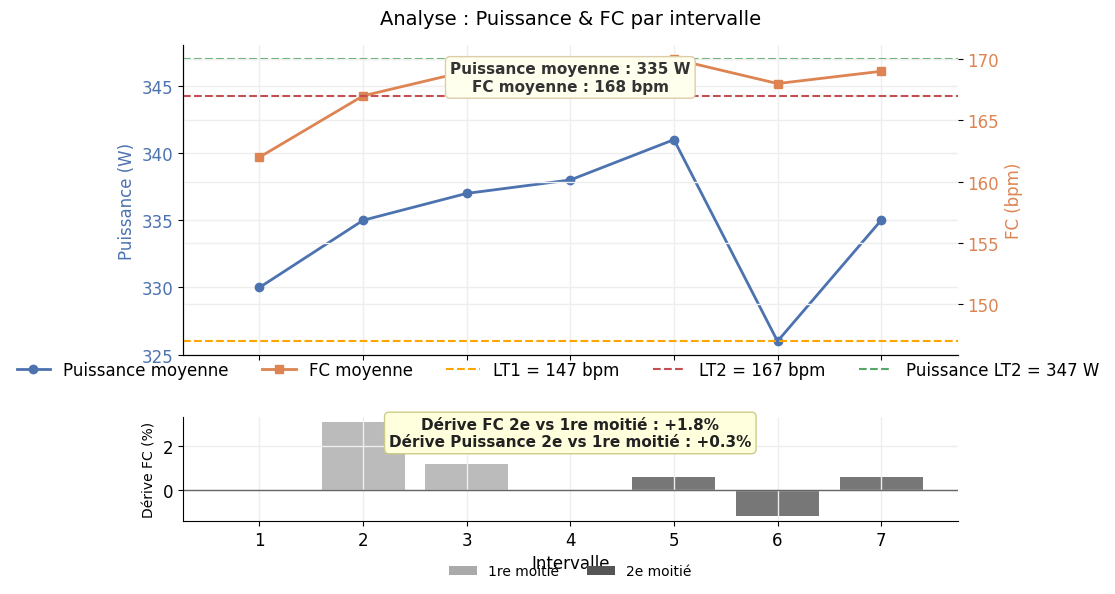

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fitdecode import FitReader, FitDataMessage
from matplotlib.patches import Patch


def read_laps_from_fit(fit_path):
    """
    Lit le fichier .FIT et extrait les laps.
    On récupère :
      - durée du lap (total_timer_time puis total_elapsed_time)
      - puissance moyenne (avg_power)
      - FC moyenne (avg_heart_rate)

    Les laps avec avg_power = 0 sont mis à NaN (ignorés ensuite).
    """
    laps = []

    with FitReader(fit_path) as fr:
        for frame in fr:
            if not isinstance(frame, FitDataMessage):
                continue
            if frame.name != "lap":
                continue

            vals = {f.name: f.value for f in frame.fields}

            timer_s   = vals.get("total_timer_time", None)
            elapsed_s = vals.get("total_elapsed_time", None)
            avg_hr    = vals.get("avg_heart_rate", None)
            avg_power = vals.get("avg_power", None)

            # durée du lap : priorité au temps de déplacement
            if timer_s is not None and timer_s > 0:
                lap_time_s = timer_s
            else:
                lap_time_s = elapsed_s

            # suppression des puissances à 0
            if avg_power is not None and avg_power == 0:
                avg_power = None

            laps.append({
                "lap_time_s": lap_time_s,
                "avg_power":  avg_power,
                "avg_hr":     avg_hr
            })

    df = pd.DataFrame(laps)

    # conversion explicite en numérique
    if not df.empty:
        df["avg_power"] = pd.to_numeric(df["avg_power"], errors="coerce")
        df["avg_hr"]    = pd.to_numeric(df["avg_hr"],    errors="coerce")

    return df


def remove_hr_artifacts(hr_series, max_delta=15):
    """
    Nettoyage des artefacts FC :
      - toute variation > max_delta bpm entre deux points consécutifs est considérée comme artefact.
      - remplacée par NaN puis interpolation linéaire.
    """
    hr = hr_series.copy().astype(float)
    diffs = hr.diff().abs()
    artifacts = diffs > max_delta
    hr[artifacts] = np.nan

    if len(hr) > 1 and pd.isna(hr.iloc[0]):
        hr.iloc[0] = hr.iloc[1]

    return hr.interpolate(method="linear")


def plot_with_hr_drift_highlight(df, lt1_hr, lt2_hr, lt2_power,
                                 drift_half_hr_pct, drift_half_power_pct):
    """
    - Haut : Puissance & FC avec LT1 / LT2 (en FC) + puissance LT2 (ligne horizontale)
    - Bas  : Dérive de FC (%) par intervalle (barres 1ère moitié vs 2ème moitié)
    """
    BLUE, RED, GREEN, PINK, ORANGE = "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#FFA500"
    DRIFT1, DRIFT2 = "#AAAAAA", "#555555"

    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.grid":        True,
        "grid.color":       "#EEEEEE",
        "grid.linestyle":   "-",
        "grid.linewidth":   1,
        "axes.spines.top":  False,
        "axes.spines.right":False,
        "font.size":        12,
    })

    x   = np.arange(1, len(df) + 1)
    mid = len(df) // 2

    mean_power = df["avg_power"].mean()
    mean_hr    = df["avg_hr_clean"].mean()
    x_center   = x.mean()
    hr_max     = df["avg_hr_clean"].max()
    annotation_y = (lt2_hr + hr_max) / 2  # milieu entre LT2 et FC max

    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(10, 7)
    )

    # --- Puissance & LT2 puissance ---
    l1, = ax1.plot(
        x, df["avg_power"],
        marker="o", color=BLUE, linewidth=2, markersize=6,
        label="Puissance moyenne"
    )
    l2 = ax1.axhline(
        lt2_power, color=GREEN, linestyle="--", linewidth=1.5,
        label=f"Puissance LT2 = {lt2_power:.0f} W"
    )
    ax1.set_ylabel("Puissance (W)", color=BLUE)
    ax1.tick_params(axis="y", labelcolor=BLUE)

    # --- FC & seuils LT1 / LT2 ---
    ax1b = ax1.twinx()
    l3, = ax1b.plot(
        x, df["avg_hr_clean"],
        marker="s", color=RED, linewidth=2, markersize=6,
        label="FC moyenne"
    )
    l5 = ax1b.axhline(
        lt1_hr, color=ORANGE, linestyle="--", linewidth=1.5,
        label=f"LT1 = {lt1_hr:.0f} bpm"
    )
    l4 = ax1b.axhline(
        lt2_hr, color=PINK, linestyle="--", linewidth=1.5,
        label=f"LT2 = {lt2_hr:.0f} bpm"
    )
    ax1b.set_ylabel("FC (bpm)", color=RED)
    ax1b.tick_params(axis="y", labelcolor=RED)

    ax1.set_title("Analyse : Puissance & FC par intervalle", pad=15, fontsize=14)

    # --- annotation des moyennes ---
    textstr = (
        f"Puissance moyenne : {mean_power:.0f} W\n"
        f"FC moyenne : {mean_hr:.0f} bpm"
    )
    ax1b.text(
        x_center, annotation_y, textstr,
        transform=ax1b.transData,
        fontsize=11, fontweight="bold", color="#333333",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFEE", ec="#DDCCAA")
    )

    # --- légende partagée ---
    handles = [l1, l3, l5, l4, l2]
    labels  = [h.get_label() for h in handles]
    fig.legend(
        handles, labels,
        loc="upper center", bbox_to_anchor=(0.5, 0.45),
        ncol=5, frameon=False
    )

    # --- barres de dérive FC par intervalle ---
    colors = [DRIFT1 if i < mid else DRIFT2 for i in range(len(df))]
    ax2.bar(x, df["hr_drift_pct"], color=colors, alpha=0.8)
    ax2.axhline(0, color="#666666", linewidth=1)

    txt = (
        f"Dérive FC 2e vs 1re moitié : {drift_half_hr_pct:+.1f}%\n"
        f"Dérive Puissance 2e vs 1re moitié : {drift_half_power_pct:+.1f}%"
    )
    ax2.text(
        0.5, 0.85, txt,
        transform=ax2.transAxes,
        fontsize=11, fontweight="bold", color="#222222",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFDD", ec="#CCCC88")
    )

    legend_patches = [
        Patch(facecolor=DRIFT1, edgecolor="none", label="1re moitié"),
        Patch(facecolor=DRIFT2, edgecolor="none", label="2e moitié")
    ]
    ax2.legend(
        handles=legend_patches,
        loc="upper center", bbox_to_anchor=(0.5, -0.3),
        ncol=2, frameon=False, fontsize=10
    )

    ax2.set_ylabel("Dérive FC (%)", fontsize=10)
    ax2.set_xlabel("Intervalle")

    fig.subplots_adjust(hspace=0.3, bottom=0.2)
    plt.show()


def main():
    print("🔸 Démarrage du script d'analyse d'intervalles (puissance + FC)...")

    fit_file_path = input("Chemin vers le fichier .FIT : ").strip()
    target_dur    = float(input("Durée d'un intervalle (s) : ").strip().replace(',', '.'))
    num_intervals = int(input("Nombre d'intervalles : ").strip())
    lt1_hr        = float(input("FC LT1 (bpm) : ").strip().replace(',', '.'))
    lt2_hr        = float(input("FC LT2 (bpm) : ").strip().replace(',', '.'))
    lt2_power     = float(input("Puissance LT2 (W) : ").strip().replace(',', '.'))

    tol          = 10  # +/- 10 s autour de la durée cible
    lower, upper = target_dur - tol, target_dur + tol

    if not os.path.isfile(fit_file_path):
        print("Fichier introuvable.")
        return

    df = read_laps_from_fit(fit_file_path)

    # filtrage sur la durée de lap
    df = df[df["lap_time_s"].between(lower, upper)].reset_index(drop=True)
    print(f"Nombre de laps après filtrage durée : {len(df)}")

    if df.empty:
        print("Aucun lap trouvé – vérifier la durée ou le fichier.")
        return

    # on saute le 1er lap (éventuel warm-up) si on a assez de tours
    if len(df) >= num_intervals + 1:
        df = df.iloc[1:num_intervals+1].reset_index(drop=True)
    else:
        print(f"Seulement {len(df)} laps disponibles, conservation de tous les laps.")

    if df.empty:
        print("Pas assez de laps après sélection.")
        return

    # nettoyage FC
    df["avg_hr_clean"] = remove_hr_artifacts(df["avg_hr"], max_delta=15)

    # dérive FC par intervalle (% vs intervalle précédent)
    df["hr_drift"] = df["avg_hr_clean"].diff().fillna(0)
    df["hr_drift_pct"] = (
        df["hr_drift"] / df["avg_hr_clean"].shift(1) * 100
    ).fillna(0)

    # dérive Puissance par intervalle (% vs intervalle précédent)
    df["power_drift"] = df["avg_power"].diff().fillna(0)
    df["power_drift_pct"] = (
        df["power_drift"] / df["avg_power"].shift(1) * 100
    ).replace([np.inf, -np.inf], np.nan).fillna(0)

    # Pa:HR par intervalle (W par bpm)
    df["pa_hr"] = df["avg_power"] / df["avg_hr_clean"]

    # dérive globale entre 1re & 2e moitié (FC & Puissance)
    mid = len(df) // 2

    first_mean_hr  = df["avg_hr_clean"].iloc[:mid].mean()
    second_mean_hr = df["avg_hr_clean"].iloc[mid:].mean()
    drift_half_hr_pct = (second_mean_hr - first_mean_hr) / first_mean_hr * 100

    first_mean_power  = df["avg_power"].iloc[:mid].mean()
    second_mean_power = df["avg_power"].iloc[mid:].mean()
    drift_half_power_pct = (second_mean_power - first_mean_power) / first_mean_power * 100

    print(f"Dérive FC globale (2e vs 1re moitié)       : {drift_half_hr_pct:+.1f}%")
    print(f"Dérive Puissance globale (2e vs 1re moitié): {drift_half_power_pct:+.1f}%")

    # on enlève les intervalles sans puissance ou FC propre
    df = df.dropna(subset=["avg_power", "avg_hr_clean"])
    if df.empty:
        print("Tous les intervalles ont une puissance nulle ou manquante.")
        return

    # affichage console rapide (optionnel)
    print("\nRésumé par intervalle :")
    print(df[["lap_time_s", "avg_power", "avg_hr_clean",
              "pa_hr", "hr_drift_pct", "power_drift_pct"]])

    plot_with_hr_drift_highlight(
        df, lt1_hr, lt2_hr, lt2_power,
        drift_half_hr_pct, drift_half_power_pct
    )


if __name__ == "__main__":
    main()


🔸 Analyse des meilleurs intervalles (puissance + FC)...
Chemin vers le fichier .FIT : /content/57606725.fit
Durée d'un intervalle (s) : 600
Nombre d'intervalles : 5
FC LT1 (bpm) : 149
FC LT2 (bpm) : 158
Puissance LT2 (W) : 364


/tmp/ipython-input-3932441396.py:59: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.resample("1S").mean()


Nombre d'intervalles trouvés : 5
Dérive FC globale (2e vs 1re moitié)       : +4.4%
Dérive Puissance globale (2e vs 1re moitié): +1.7%

Résumé par intervalle :
   lap_time_s   avg_power  avg_hr_clean     pa_hr  hr_drift_pct  \
0         600  356.236667    144.831667  2.459660      0.000000   
1         600  360.915000    149.778333  2.409661      3.415459   
2         600  362.106667    152.190000  2.379307      1.610157   
3         600  362.763333    153.208333  2.367778      0.669120   
4         600  368.758333    155.988333  2.364012      1.814523   

   power_drift_pct  
0         0.000000  
1         1.313266  
2         0.330179  
3         0.181346  
4         1.652593  


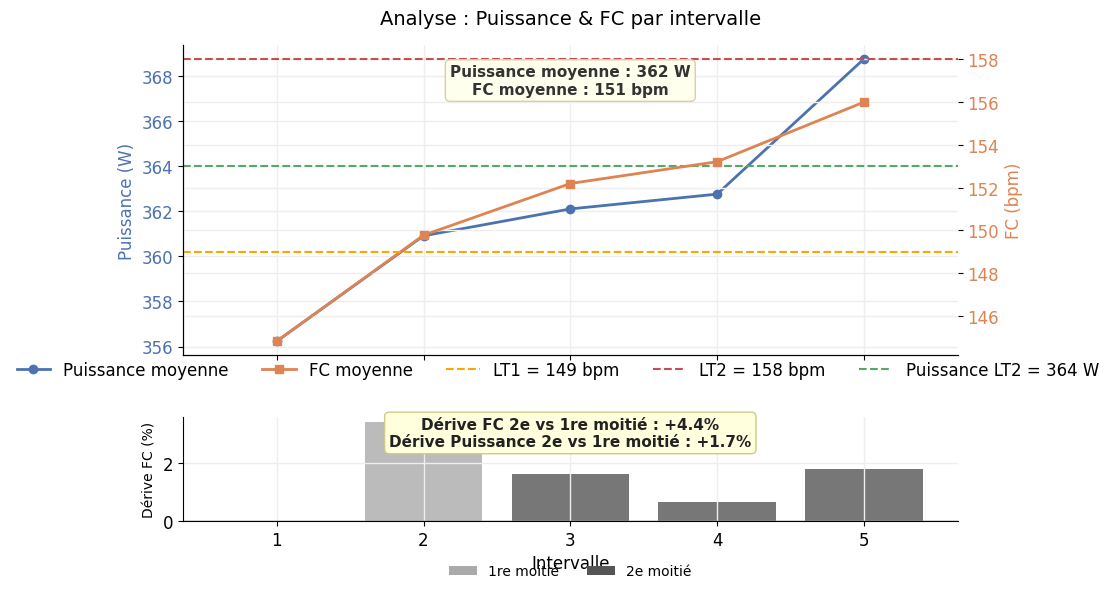

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fitdecode import FitReader, FitDataMessage
from matplotlib.patches import Patch


# ========= LECTURE & NETTOYAGE =========

def read_records_from_fit(fit_path):
    """
    Lit le fichier .FIT et extrait les enregistrements 'record'.
    On récupère :
      - timestamp
      - puissance (power)
      - fréquence cardiaque (heart_rate)

    Les données sont ensuite resamplées à 1 s.
    """
    records = []

    with FitReader(fit_path) as fr:
        for frame in fr:
            if not isinstance(frame, FitDataMessage):
                continue
            if frame.name != "record":
                continue

            vals = {f.name: f.value for f in frame.fields}
            ts   = vals.get("timestamp", None)
            pw   = vals.get("power", None)
            hr   = vals.get("heart_rate", None)

            if ts is None:
                continue

            records.append({
                "timestamp": pd.to_datetime(ts),
                "power": pw,
                "hr": hr
            })

    df = pd.DataFrame(records)
    if df.empty:
        return df

    df = df.sort_values("timestamp")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp")

    df["power"] = pd.to_numeric(df["power"], errors="coerce")
    df["hr"]    = pd.to_numeric(df["hr"],    errors="coerce")

    # Resample à 1 s
    df = df.resample("1S").mean()

    # Interpolation / remplissage basique
    df["power"] = df["power"].interpolate("linear").fillna(0)
    df["hr"]    = df["hr"].interpolate("linear")

    # Temps en secondes depuis le début
    df["t_sec"] = (df.index - df.index[0]).total_seconds().astype(int)

    return df.reset_index()  # timestamp redevient une colonne


def remove_hr_artifacts(hr_series, max_delta=15):
    """
    Nettoyage des artefacts FC :
      - toute variation > max_delta bpm entre deux points consécutifs est considérée comme artefact.
      - remplacée par NaN puis interpolation linéaire.
    """
    hr = hr_series.copy().astype(float)
    diffs = hr.diff().abs()
    artifacts = diffs > max_delta
    hr[artifacts] = np.nan

    if len(hr) > 1 and pd.isna(hr.iloc[0]):
        hr.iloc[0] = hr.iloc[1]

    return hr.interpolate(method="linear")


# ========= RECHERCHE DES MEILLEURS INTERVALLES =========

def find_best_intervals(df, target_dur_s, num_intervals):
    """
    Trouve les `num_intervals` meilleures fenêtres de `target_dur_s` secondes
    en termes de puissance moyenne, sans chevauchement.

    df doit contenir :
      - colonne 'power'
      - colonne 'hr_clean'
      - colonne 't_sec'
    """
    # Durée en nombre d'échantillons (1 échantillon = 1 s)
    window = int(round(target_dur_s))
    if window <= 0:
        raise ValueError("Durée d'intervalle invalide.")

    if len(df) < window:
        print("La séance est plus courte que la durée de fenêtre demandée.")
        return pd.DataFrame()

    power = df["power"].values
    hr_clean = df["hr_clean"].values
    t_sec = df["t_sec"].values

    windows = []
    # On parcourt tous les indices finaux possibles
    for end_idx in range(window - 1, len(df)):
        start_idx = end_idx - window + 1
        segment_power = power[start_idx:end_idx + 1]
        segment_hr    = hr_clean[start_idx:end_idx + 1]

        mean_p  = np.nanmean(segment_power)
        mean_hr = np.nanmean(segment_hr)

        windows.append({
            "start_idx": start_idx,
            "end_idx": end_idx,
            "mean_power": mean_p,
            "mean_hr_clean": mean_hr
        })

    windows_df = pd.DataFrame(windows)

    # On classe les fenêtres par puissance décroissante
    windows_df = windows_df.sort_values("mean_power", ascending=False).reset_index(drop=True)

    # Sélection des N meilleures fenêtres non chevauchantes
    selected = []
    for _, row in windows_df.iterrows():
        s = int(row["start_idx"])
        e = int(row["end_idx"])

        overlap = False
        for (s2, e2, _) in selected:
            # chevauchement si les intervalles s-e et s2-e2 se recoupent
            if not (e < s2 or s > e2):
                overlap = True
                break

        if overlap:
            continue

        selected.append((s, e, row))

        if len(selected) >= num_intervals:
            break

    if not selected:
        return pd.DataFrame()

    # Reconstruction des intervalles dans l'ordre chronologique
    selected_sorted = sorted(selected, key=lambda x: x[0])

    intervals = []
    for (s, e, row) in selected_sorted:
        duration = t_sec[e] - t_sec[s] + 1  # en secondes
        intervals.append({
            "lap_time_s": duration,
            "avg_power": row["mean_power"],
            "avg_hr_clean": row["mean_hr_clean"]
        })

    return pd.DataFrame(intervals)


# ========= PLOT =========

def plot_with_hr_drift_highlight(df, lt1_hr, lt2_hr, lt2_power,
                                 drift_half_hr_pct, drift_half_power_pct):
    """
    - Haut : Puissance & FC avec LT1 / LT2 (en FC) + puissance LT2 (ligne horizontale)
    - Bas  : Dérive de FC (%) par intervalle (barres 1ère moitié vs 2ème moitié)
    """
    BLUE, RED, GREEN, PINK, ORANGE = "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#FFA500"
    DRIFT1, DRIFT2 = "#AAAAAA", "#555555"

    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.grid":        True,
        "grid.color":       "#EEEEEE",
        "grid.linestyle":   "-",
        "grid.linewidth":   1,
        "axes.spines.top":  False,
        "axes.spines.right":False,
        "font.size":        12,
    })

    x   = np.arange(1, len(df) + 1)
    mid = len(df) // 2

    mean_power = df["avg_power"].mean()
    mean_hr    = df["avg_hr_clean"].mean()
    x_center   = x.mean()
    hr_max     = df["avg_hr_clean"].max()
    annotation_y = (lt2_hr + hr_max) / 2  # milieu entre LT2 et FC max

    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(10, 7)
    )

    # --- Puissance & LT2 puissance ---
    l1, = ax1.plot(
        x, df["avg_power"],
        marker="o", linewidth=2, markersize=6,
        color=BLUE, label="Puissance moyenne"
    )
    l2 = ax1.axhline(
        lt2_power, color=GREEN, linestyle="--", linewidth=1.5,
        label=f"Puissance LT2 = {lt2_power:.0f} W"
    )
    ax1.set_ylabel("Puissance (W)", color=BLUE)
    ax1.tick_params(axis="y", labelcolor=BLUE)

    # --- FC & seuils LT1 / LT2 ---
    ax1b = ax1.twinx()
    l3, = ax1b.plot(
        x, df["avg_hr_clean"],
        marker="s", linewidth=2, markersize=6,
        color=RED, label="FC moyenne"
    )
    l5 = ax1b.axhline(
        lt1_hr, color=ORANGE, linestyle="--", linewidth=1.5,
        label=f"LT1 = {lt1_hr:.0f} bpm"
    )
    l4 = ax1b.axhline(
        lt2_hr, color=PINK, linestyle="--", linewidth=1.5,
        label=f"LT2 = {lt2_hr:.0f} bpm"
    )
    ax1b.set_ylabel("FC (bpm)", color=RED)
    ax1b.tick_params(axis="y", labelcolor=RED)

    ax1.set_title("Analyse : Puissance & FC par intervalle", pad=15, fontsize=14)

    # --- annotation des moyennes ---
    textstr = (
        f"Puissance moyenne : {mean_power:.0f} W\n"
        f"FC moyenne : {mean_hr:.0f} bpm"
    )
    ax1b.text(
        x_center, annotation_y, textstr,
        transform=ax1b.transData,
        fontsize=11, fontweight="bold", color="#333333",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFEE", ec="#DDCCAA")
    )

    # --- légende partagée ---
    handles = [l1, l3, l5, l4, l2]
    labels  = [h.get_label() for h in handles]
    fig.legend(
        handles, labels,
        loc="upper center", bbox_to_anchor=(0.5, 0.45),
        ncol=5, frameon=False
    )

    # --- barres de dérive FC par intervalle ---
    colors = [DRIFT1 if i < mid else DRIFT2 for i in range(len(df))]
    ax2.bar(x, df["hr_drift_pct"], color=colors, alpha=0.8)
    ax2.axhline(0, color="#666666", linewidth=1)

    txt = (
        f"Dérive FC 2e vs 1re moitié : {drift_half_hr_pct:+.1f}%\n"
        f"Dérive Puissance 2e vs 1re moitié : {drift_half_power_pct:+.1f}%"
    )
    ax2.text(
        0.5, 0.85, txt,
        transform=ax2.transAxes,
        fontsize=11, fontweight="bold", color="#222222",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFDD", ec="#CCCC88")
    )

    legend_patches = [
        Patch(facecolor=DRIFT1, edgecolor="none", label="1re moitié"),
        Patch(facecolor=DRIFT2, edgecolor="none", label="2e moitié")
    ]
    ax2.legend(
        handles=legend_patches,
        loc="upper center", bbox_to_anchor=(0.5, -0.3),
        ncol=2, frameon=False, fontsize=10
    )

    ax2.set_ylabel("Dérive FC (%)", fontsize=10)
    ax2.set_xlabel("Intervalle")

    fig.subplots_adjust(hspace=0.3, bottom=0.2)
    plt.show()


# ========= MAIN =========

def main():
    print("🔸 Analyse des meilleurs intervalles (puissance + FC)...")

    fit_file_path = input("Chemin vers le fichier .FIT : ").strip()
    target_dur    = float(input("Durée d'un intervalle (s) : ").strip().replace(',', '.'))
    num_intervals = int(input("Nombre d'intervalles : ").strip())
    lt1_hr        = float(input("FC LT1 (bpm) : ").strip().replace(',', '.'))
    lt2_hr        = float(input("FC LT2 (bpm) : ").strip().replace(',', '.'))
    lt2_power     = float(input("Puissance LT2 (W) : ").strip().replace(',', '.'))

    if not os.path.isfile(fit_file_path):
        print("Fichier introuvable.")
        return

    # Lecture des records
    df_rec = read_records_from_fit(fit_file_path)
    if df_rec.empty:
        print("Aucun enregistrement 'record' trouvé dans le fichier.")
        return

    # Nettoyage FC
    df_rec["hr_clean"] = remove_hr_artifacts(df_rec["hr"], max_delta=15)

    # Recherche des meilleurs intervalles
    df = find_best_intervals(df_rec, target_dur, num_intervals)
    print(f"Nombre d'intervalles trouvés : {len(df)}")

    if df.empty:
        print("Aucun intervalle trouvé.")
        return

    # Dérive FC par intervalle (% vs intervalle précédent)
    df["hr_drift"] = df["avg_hr_clean"].diff().fillna(0)
    df["hr_drift_pct"] = (
        df["hr_drift"] / df["avg_hr_clean"].shift(1) * 100
    ).fillna(0)

    # Dérive Puissance par intervalle (% vs intervalle précédent)
    df["power_drift"] = df["avg_power"].diff().fillna(0)
    df["power_drift_pct"] = (
        df["power_drift"] / df["avg_power"].shift(1) * 100
    ).replace([np.inf, -np.inf], np.nan).fillna(0)

    # Pa:HR par intervalle
    df["pa_hr"] = df["avg_power"] / df["avg_hr_clean"]

    # Dérive globale entre 1re & 2e moitié
    mid = len(df) // 2

    first_mean_hr  = df["avg_hr_clean"].iloc[:mid].mean()
    second_mean_hr = df["avg_hr_clean"].iloc[mid:].mean()
    drift_half_hr_pct = (second_mean_hr - first_mean_hr) / first_mean_hr * 100

    first_mean_power  = df["avg_power"].iloc[:mid].mean()
    second_mean_power = df["avg_power"].iloc[mid:].mean()
    drift_half_power_pct = (second_mean_power - first_mean_power) / first_mean_power * 100

    print(f"Dérive FC globale (2e vs 1re moitié)       : {drift_half_hr_pct:+.1f}%")
    print(f"Dérive Puissance globale (2e vs 1re moitié): {drift_half_power_pct:+.1f}%")

    # Affichage console
    print("\nRésumé par intervalle :")
    print(df[["lap_time_s", "avg_power", "avg_hr_clean",
              "pa_hr", "hr_drift_pct", "power_drift_pct"]])

    # Graphique
    plot_with_hr_drift_highlight(
        df, lt1_hr, lt2_hr, lt2_power,
        drift_half_hr_pct, drift_half_power_pct
    )


if __name__ == "__main__":
    main()


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fitdecode import FitReader, FitDataMessage
from matplotlib.patches import Patch


def read_laps_from_fit(fit_path):
    """
    Read the .FIT file and extract 'lap' messages with fitdecode.
    ALWAYS compute average speed from distance / time (km/h).
    Priority:
      - total_timer_time (moving time)
      - then total_elapsed_time
    """
    laps = []

    with FitReader(fit_path) as fr:
        for frame in fr:
            if not isinstance(frame, FitDataMessage):
                continue
            if frame.name != "lap":
                continue

            vals = {f.name: f.value for f in frame.fields}

            timer_s   = vals.get("total_timer_time", None)
            elapsed_s = vals.get("total_elapsed_time", None)
            distance  = vals.get("total_distance", None)
            avg_hr    = vals.get("avg_heart_rate", None)

            # choose lap time: timer_time (moving) first, else elapsed
            lap_time_s = timer_s if (timer_s is not None and timer_s > 0) else elapsed_s

            # compute average speed from distance / time
            if lap_time_s and distance and lap_time_s > 0:
                speed_kmh = (distance / lap_time_s) * 3.6
            else:
                speed_kmh = None

            laps.append({
                "lap_time_s":    lap_time_s,
                "avg_speed_kmh": speed_kmh,
                "avg_hr":        avg_hr
            })

    return pd.DataFrame(laps)


def remove_hr_artifacts(hr_series, max_delta=15):
    """
    Remove HR artifacts:
      - any jump > max_delta bpm is considered an artifact
      - replace artifacts with NaN, then linearly interpolate
    """
    hr = hr_series.copy().astype(float)
    diffs = hr.diff().abs()
    artifacts = diffs > max_delta
    hr[artifacts] = np.nan
    if pd.isna(hr.iloc[0]) and len(hr) > 1:
        hr.iloc[0] = hr.iloc[1]
    return hr.interpolate(method="linear")


def plot_with_hr_drift_highlight(df, lt1_hr, lt2_hr, lt2_speed, drift_half_pct):
    """
    - Top: speed & HR with LT1 & LT2 thresholds + overall means annotation on HR axis
    - Shared legend between subplots
    - Bottom: HR drift (%) as bars (1st vs 2nd half)
    """
    BLUE, RED, GREEN, PINK, ORANGE = "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#FFA500"
    DRIFT1, DRIFT2                = "#AAAAAA", "#555555"

    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.grid":        True,
        "grid.color":       "#EEEEEE",
        "grid.linestyle":   "-",
        "grid.linewidth":   1,
        "axes.spines.top":  False,
        "axes.spines.right":False,
        "font.size":        12,
    })

    x   = np.arange(1, len(df) + 1)
    mid = len(df) // 2

    # compute overall means
    mean_speed = df["avg_speed_kmh"].mean()
    mean_hr    = df["avg_hr_clean"].mean()
    x_center   = x.mean()
    hr_max     = df["avg_hr_clean"].max()
    annotation_y = (lt2_hr + hr_max) / 2  # midway between LT2 and max HR

    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1,
        sharex=True,
        gridspec_kw={"height_ratios":[3,1]},
        figsize=(10,7)
    )

    # --- Speed & LT2 speed threshold ---
    l1, = ax1.plot(
        x, df["avg_speed_kmh"],
        marker="o", color=BLUE, linewidth=2, markersize=6,
        label="Average speed"
    )
    l2 = ax1.axhline(
        lt2_speed, color=GREEN, linestyle="--", linewidth=1.5,
        label=f"LT2 speed = {lt2_speed:.1f} km/h"
    )
    ax1.set_ylabel("Speed (km/h)", color=BLUE)
    ax1.tick_params(axis="y", labelcolor=BLUE)

    # --- HR & LT1 & LT2 HR thresholds ---
    ax1b = ax1.twinx()
    l3, = ax1b.plot(
        x, df["avg_hr_clean"],
        marker="s", color=RED, linewidth=2, markersize=6,
        label="Average HR"
    )
    l5 = ax1b.axhline(
        lt1_hr, color=ORANGE, linestyle="--", linewidth=1.5,
        label=f"LT1 HR = {lt1_hr:.0f} bpm"
    )
    l4 = ax1b.axhline(
        lt2_hr, color=PINK, linestyle="--", linewidth=1.5,
        label=f"LT2 HR = {lt2_hr:.0f} bpm"
    )
    ax1b.set_ylabel("HR (bpm)", color=RED)
    ax1b.tick_params(axis="y", labelcolor=RED)

    ax1.set_title("Analysis: Speed & HR per Interval", pad=15, fontsize=14)

    # --- annotate overall means on HR axis ---
    textstr = (
        f"Mean speed: {mean_speed:.1f} km/h\n"
        f"Mean HR:    {mean_hr:.0f} bpm"
    )
    ax1b.text(
        x_center, annotation_y, textstr,
        transform=ax1b.transData,
        fontsize=11, fontweight="bold", color="#333333",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFEE", ec="#DDCCAA")
    )

    # --- shared legend (includes all lines + thresholds) ---
    handles = [l1, l3, l5, l4, l2]
    labels  = [h.get_label() for h in handles]
    fig.legend(
        handles, labels,
        loc="upper center", bbox_to_anchor=(0.5, 0.45),
        ncol=5, frameon=False
    )

    # --- HR drift bars ---
    colors = [DRIFT1 if i < mid else DRIFT2 for i in range(len(df))]
    ax2.bar(x, df["hr_drift_pct"], color=colors, alpha=0.8)
    ax2.axhline(0, color="#666666", linewidth=1)

    txt = f"HR drift 2nd vs 1st half: {drift_half_pct:+.1f}%"
    ax2.text(
        0.5, 0.85, txt,
        transform=ax2.transAxes,
        fontsize=11, fontweight="bold", color="#222222",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFDD", ec="#CCCC88")
    )

    legend_patches = [
        Patch(facecolor=DRIFT1, edgecolor="none", label="1st half"),
        Patch(facecolor=DRIFT2, edgecolor="none", label="2nd half")
    ]
    ax2.legend(
        handles=legend_patches,
        loc="upper center", bbox_to_anchor=(0.5, -0.3),
        ncol=2, frameon=False, fontsize=10
    )

    ax2.set_ylabel("HR Drift (%)", fontsize=10)
    ax2.set_xlabel("Interval")

    fig.subplots_adjust(hspace=0.3, bottom=0.2)
    plt.show()


def main():
    print("🔸 Starting interval analysis script...")

    fit_file_path = input("Path to the .FIT file: ").strip()
    target_dur    = float(input("Interval duration (s): ").strip().replace(',', '.'))
    num_intervals = int(input("Number of intervals: ").strip())
    lt1_hr        = float(input("LT1 HR (bpm): ").strip().replace(',', '.'))
    lt2_hr        = float(input("LT2 HR (bpm): ").strip().replace(',', '.'))
    lt2_speed     = float(input("LT2 speed (km/h): ").strip().replace(',', '.'))

    tol          = 10
    lower, upper = target_dur - tol, target_dur + tol

    if not os.path.isfile(fit_file_path):
        print("File not found.")
        return

    df = read_laps_from_fit(fit_file_path)
    df = df[df["lap_time_s"].between(lower, upper)].reset_index(drop=True)
    print(f"Laps after filtering: {len(df)}")
    if df.empty:
        print("No laps found – check duration or file.")
        return

    # skip warm-up lap
    if len(df) >= num_intervals + 1:
        df = df.iloc[1:num_intervals+1].reset_index(drop=True)
    else:
        print(f"Only {len(df)} laps available, keeping all.")
    if df.empty:
        print("Not enough laps after selection.")
        return

    # clean HR and compute drift
    df["avg_hr_clean"] = remove_hr_artifacts(df["avg_hr"], max_delta=15)
    df["hr_drift"]     = df["avg_hr_clean"].diff().fillna(0)
    df["hr_drift_pct"] = (df["hr_drift"] / df["avg_hr_clean"].shift(1) * 100).fillna(0)

    mid            = len(df) // 2
    first_mean_hr  = df["avg_hr_clean"].iloc[:mid].mean()
    second_mean_hr = df["avg_hr_clean"].iloc[mid:].mean()
    drift_half_pct = (second_mean_hr - first_mean_hr) / first_mean_hr * 100
    print(f"Global HR drift (2nd vs 1st half): {drift_half_pct:+.1f}%")

    plot_with_hr_drift_highlight(df, lt1_hr, lt2_hr, lt2_speed, drift_half_pct)


if __name__ == "__main__":
    main()


🔸 Starting interval analysis script...
Path to the .FIT file: /content/57622129.fit
Interval duration (s): 360
Number of intervals: 5
LT1 HR (bpm): 159
LT2 HR (bpm): 173
LT2 speed (km/h): 17.8
Laps after filtering: 0
No laps found – check duration or file.
